# Emerging Tech Lab - Plotting Calibration Curves

## Calibration curve before optimisation

   Target Dispense  Actual Dispense  Actual Dispense Std
0               40         8.886203             6.276414
1               80        46.714119             9.398462
2              120       102.448742             0.911694
3              140       121.429850             3.668963
4              160       142.403080             3.139823
5              200       186.543110             8.672774
6              220       212.463067            11.809075


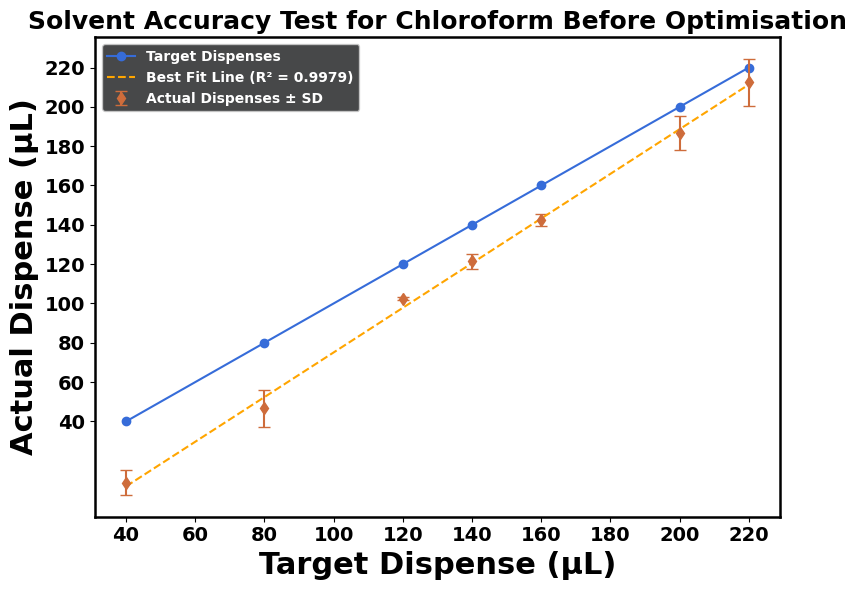

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

chcl3_density = 1.4892  # g/mL

##################################INSERT WEIGHTS HERE!!########################################
# First copy and paste your dispenses dictonary below, replacing the existing dispenses dictonary.
dispenses = {
    'A1': 40, 'A2': 80, 'A3': 120, 'A4': 140, 'A5': 160, 'A6': 200, 'A7': 220, 'A8': 0,
    'B1': 40, 'B2': 80, 'B3': 120, 'B4': 140, 'B5': 160, 'B6': 200, 'B7': 220, 'B8': 0,
    'C1': 40, 'C2': 80, 'C3': 120, 'C4': 140, 'C5': 160, 'C6': 200, 'C7': 220, 'C8': 0,
    'D1': 0, 'D2': 0, 'D3': 0, 'D4': 0, 'D5': 0, 'D6': 0, 'D7': 0, 'D8': 0,
    'E1': 0, 'E2': 0, 'E3': 0, 'E4': 0, 'E5': 0, 'E6': 0, 'E7': 0, 'E8': 0,
    'F1': 0, 'F2': 0, 'F3': 0, 'F4': 0, 'F5': 0, 'F6': 0, 'F7': 0, 'F8': 0
}


mass_of_vol_dispensed = {
    'A1': 64.9, 'A2': 58.5, 'A3': 153.4, 'A4': 179.3, 'A5': 207.7, 'A6': 264.2, 'A7': 296.1, 'A8': 0,
    'B1': 7.2, 'B2': 24, 'B3': 151, 'B4': 176.3, 'B5': 217, 'B6': 279.3, 'B7': 327, 'B8': 0,
    'C1': 8.5, 'C2': 85.3, 'C3': 153.3, 'C4': 186.9, 'C5': 211.5, 'C6': 289.9, 'C7': 326.1, 'C8': 0,
    'D1': 0, 'D2': 0, 'D3': 0, 'D4': 0, 'D5': 0, 'D6': 0, 'D7': 0, 'D8': 0,
    'E1': 0, 'E2': 0, 'E3': 0, 'E4': 0, 'E5': 0, 'E6': 0, 'E7': 0, 'E8': 0,
    'F1': 0, 'F2': 0, 'F3': 0, 'F4': 0, 'F5': 0, 'F6': 0, 'F7': 0, 'F8': 0
}
#################################################################################################

# Sort and convert to volumes
sorted_masses = dict(sorted(mass_of_vol_dispensed.items(), key=lambda mass: mass[1])) # Sorting masses by matching ones that should have the same dispense (A1, B1 C1 e.t.c...)
vol_dispensed = [(mass / chcl3_density) for mass in sorted_masses.values()] # Calculating actual volume of chloroform dispensed using density
vol_dispensed = list(filter(lambda mass: mass != 0, vol_dispensed)) # Removing any null values

# Average every 3 replicates and calculate standard deviation for error bars
actual_dispense = [np.mean(vol_dispensed[i:i+3]) for i in range(0, len(vol_dispensed), 3)]
actual_dispense_std = [np.std(vol_dispensed[i:i+3], ddof=1) for i in range(0, len(vol_dispensed), 3)]
target_dispense = sorted(set(filter(lambda x: x != 0, dispenses.values())))

# Creating dataframe
try:
    df = pd.DataFrame({
        "Target Dispense": target_dispense,
        "Actual Dispense": actual_dispense,
        "Actual Dispense Std": actual_dispense_std,
    })
except ValueError:
    raise ValueError("Make sure that your dispenses dict and your mass of vol dispensed dict match up!")

# Line of best fit
slope, intercept = np.polyfit(df["Target Dispense"], df["Actual Dispense"], 1)
best_fit = np.poly1d((slope, intercept))

# R-squared calculation
predicted = best_fit(df["Target Dispense"])
r_squared = 1 - np.sum((df["Actual Dispense"] - predicted) ** 2) / np.sum((df["Actual Dispense"] - np.mean(df["Actual Dispense"])) ** 2)

# Plotting
fig, ax = plt.subplots(figsize=(8, 6), facecolor="white")
ax.set_facecolor("white")
ax.tick_params(axis="both", colors="black", labelcolor="black")
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.8)
    spine.set_color("black")

plt.plot(df["Target Dispense"], df["Target Dispense"], "-o", label="Target Dispenses", markersize=6)
plt.errorbar(
    df["Target Dispense"],
    df["Actual Dispense"],
    yerr=df["Actual Dispense Std"],
    fmt="d",
    capsize=4,
    elinewidth=1.5,
    label="Actual Dispenses ± SD",
    markersize=6,
)
plt.plot(df["Target Dispense"], predicted, color='orange', linestyle='--', label=f'Best Fit Line (R² = {r_squared:.4f})')

plt.title("Solvent Accuracy Test for Chloroform Before Optimisation", fontsize=18, fontweight='bold', color="black")
plt.xlabel("Target Dispense (µL)", fontsize=22, fontweight='bold', color="black")
plt.ylabel("Actual Dispense (µL)", fontsize=22, fontweight='bold', color="black")
plt.xticks(np.arange(min(target_dispense), max(target_dispense)+1, 20), fontsize=14, fontweight='bold', color="black")
plt.yticks(np.arange(min(target_dispense), max(target_dispense)+1, 20), fontsize=14, fontweight='bold', color="black")
plt.legend(prop={"size":10, "weight":'bold'}, loc='upper left')
plt.tight_layout()
plt.savefig(
    "accuracy_test_chloroform_before_optimisation.pdf",
    facecolor="white",
    edgecolor="white",
    bbox_inches="tight",
)
plt.show()

## Calibration curve after optimisation

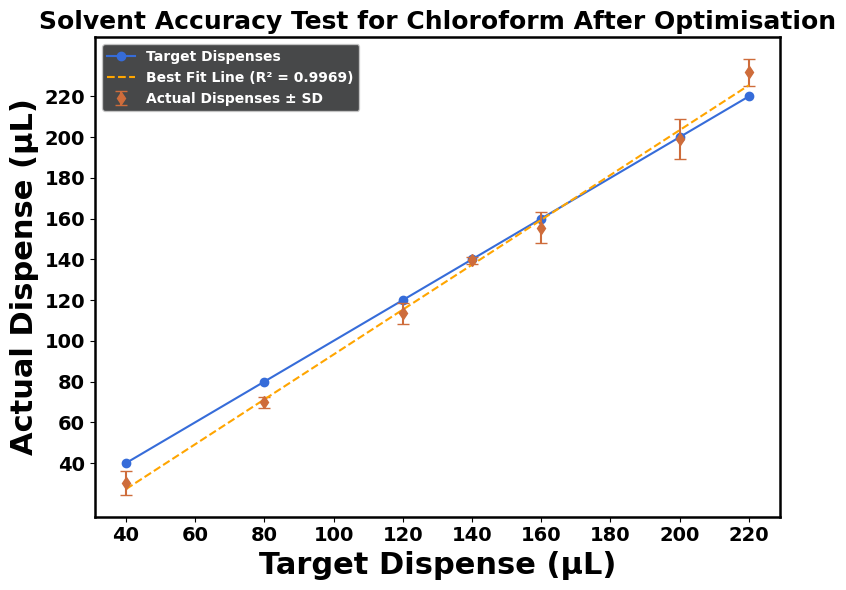

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

chcl3_density = 1.4892  # g/mL

##################################INSERT WEIGHTS HERE!!########################################
# First copy and paste your dispenses dictionary below, replacing the existing dispenses dictionary.
dispenses = {
    'A1': 40, 'A2': 80, 'A3': 120, 'A4': 140, 'A5': 160, 'A6': 200, 'A7': 220, 'A8': 0,
    'B1': 40, 'B2': 80, 'B3': 120, 'B4': 140, 'B5': 160, 'B6': 200, 'B7': 220, 'B8': 0,
    'C1': 40, 'C2': 80, 'C3': 120, 'C4': 140, 'C5': 160, 'C6': 200, 'C7': 220, 'C8': 0,
    'D1': 0, 'D2': 0, 'D3': 0, 'D4': 0, 'D5': 0, 'D6': 0, 'D7': 0, 'D8': 0,
    'E1': 0, 'E2': 0, 'E3': 0, 'E4': 0, 'E5': 0, 'E6': 0, 'E7': 0, 'E8': 0,
    'F1': 0, 'F2': 0, 'F3': 0, 'F4': 0, 'F5': 0, 'F6': 0, 'F7': 0, 'F8': 0
}

mass_of_vol_dispensed = {
    'A1': 36.5, 'A2': 101.2, 'A3': 159.9, 'A4': 205.3, 'A5': 222, 'A6': 280, 'A7': 334.4, 'A8': 0,
    'B1': 53.8, 'B2': 108.5, 'B3': 174.4, 'B4': 210.7, 'B5': 244.1, 'B6': 308.8, 'B7': 353, 'B8': 0,
    'C1': 44.4, 'C2': 102.4, 'C3': 172.4, 'C4': 207.5, 'C5': 228.8, 'C6': 300.6, 'C7': 348.2, 'C8': 0,
    'D1': 0, 'D2': 0, 'D3': 0, 'D4': 0, 'D5': 0, 'D6': 0, 'D7': 0, 'D8': 0,
    'E1': 0, 'E2': 0, 'E3': 0, 'E4': 0, 'E5': 0, 'E6': 0, 'E7': 0, 'E8': 0,
    'F1': 0, 'F2': 0, 'F3': 0, 'F4': 0, 'F5': 0, 'F6': 0, 'F7': 0, 'F8': 0
}
#################################################################################################

# Sort and convert to volumes.
# If mass is recorded in mg and density is in g/mL, then mass / density gives volume in uL directly.
sorted_masses = dict(sorted(mass_of_vol_dispensed.items(), key=lambda mass: mass[1]))
vol_dispensed = [(mass / chcl3_density) for mass in sorted_masses.values()]
vol_dispensed = list(filter(lambda mass: mass != 0, vol_dispensed))

# Average every 3 replicates and calculate standard deviation for error bars
actual_dispense = [np.mean(vol_dispensed[i:i+3]) for i in range(0, len(vol_dispensed), 3)]
actual_dispense_std = [np.std(vol_dispensed[i:i+3], ddof=1) for i in range(0, len(vol_dispensed), 3)]
target_dispense = sorted(set(filter(lambda x: x != 0, dispenses.values())))

# Creating dataframe
try:
    df = pd.DataFrame({
        "Target Dispense": target_dispense,
        "Actual Dispense": actual_dispense,
        "Actual Dispense Std": actual_dispense_std,
    })
except ValueError:
    raise ValueError("Make sure that your dispenses dict and your mass of vol dispensed dict match up!")

# Line of best fit
slope, intercept = np.polyfit(df["Target Dispense"], df["Actual Dispense"], 1)
best_fit = np.poly1d((slope, intercept))

# R-squared calculation
predicted = best_fit(df["Target Dispense"])
r_squared = 1 - np.sum((df["Actual Dispense"] - predicted) ** 2) / np.sum((df["Actual Dispense"] - np.mean(df["Actual Dispense"])) ** 2)

# Plotting: matched to the before-optimisation style
fig, ax = plt.subplots(figsize=(8, 6), facecolor="white")
ax.set_facecolor("white")
ax.tick_params(axis="both", colors="black", labelcolor="black")

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.8)
    spine.set_color("black")

plt.plot(df["Target Dispense"], df["Target Dispense"], "-o", label="Target Dispenses", markersize=6)
plt.errorbar(
    df["Target Dispense"],
    df["Actual Dispense"],
    yerr=df["Actual Dispense Std"],
    fmt="d",
    capsize=4,
    elinewidth=1.5,
    label="Actual Dispenses ± SD",
    markersize=6,
)
plt.plot(df["Target Dispense"], predicted, color='orange', linestyle='--', label=f'Best Fit Line (R² = {r_squared:.4f})')

plt.title("Solvent Accuracy Test for Chloroform After Optimisation", fontsize=18, fontweight="bold", color="black")
plt.xlabel("Target Dispense (µL)", fontsize=22, fontweight="bold", color="black")
plt.ylabel("Actual Dispense (µL)", fontsize=22, fontweight="bold", color="black")
plt.xticks(np.arange(min(target_dispense), max(target_dispense)+1, 20), fontsize=14, fontweight="bold", color="black")
plt.yticks(np.arange(min(target_dispense), max(target_dispense)+1, 20), fontsize=14, fontweight="bold", color="black")
plt.legend(prop={"size": 10, "weight": "bold"}, loc="upper left")
plt.tight_layout()
plt.savefig(
    "accuracy_test_chloroform_after_optimisation.pdf",
    facecolor="white",
    edgecolor="white",
    bbox_inches="tight",
)
plt.show()